# 🌿 Level 1 — Task 1: Data Preprocessing for Machine Learning
**Intern:** Amos Njama Mungai | **Company:** Codveda Technologies

**Dataset:** Iris Dataset (1) iris.csv)

**Objectives:**
- Handle missing data
- Encode categorical variables
- Normalize / Standardize numerical features
- Split dataset into training and testing sets

**Tools:** Python, Pandas, Scikit-learn

## Step 1: Mount Google Drive


In [7]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted successfully')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Data Set For Task/1) iris.csv')
print('✅ Dataset loaded successfully')
print(f'Shape: {df.shape}')
df.head(10)

✅ Dataset loaded successfully
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## Step 3: Import Libraries

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## Step 4: Explore the Dataset

In [10]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [11]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


=== Class Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


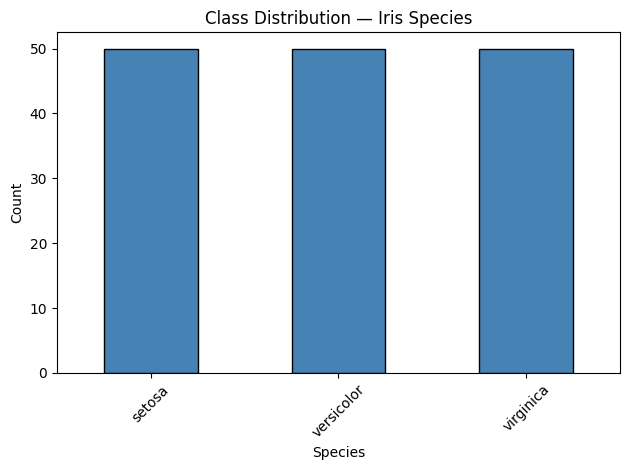

In [12]:
print('=== Class Distribution ===')
print(df['species'].value_counts())

df['species'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution — Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 5: Handle Missing Data

=== Missing Values per Column ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing values: 0


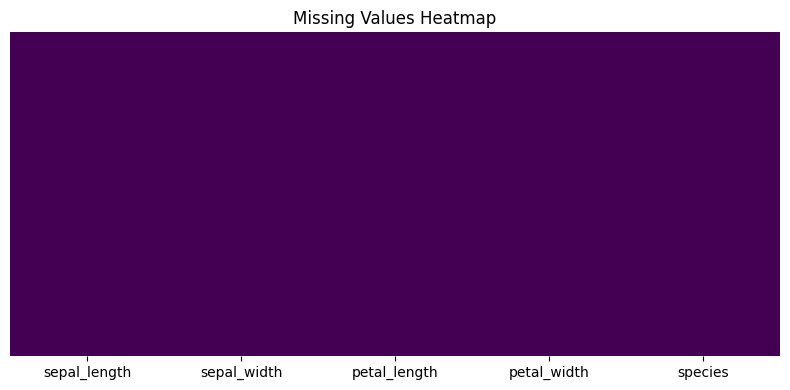

In [13]:
print('=== Missing Values per Column ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [14]:

numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())


categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'✅ Missing values after handling: {df.isnull().sum().sum()}')

✅ Missing values after handling: 0


## Step 6: Encode Categorical Variables

In [15]:
print('=== Original species column ===')
print(df['species'].unique())


le = LabelEncoder()
df['species_label_encoded'] = le.fit_transform(df['species'])
print('\n=== After Label Encoding ===')
print(df[['species', 'species_label_encoded']].drop_duplicates())

=== Original species column ===
['setosa' 'versicolor' 'virginica']

=== After Label Encoding ===
        species  species_label_encoded
0        setosa                      0
50   versicolor                      1
100   virginica                      2


In [16]:
# One-Hot Encoding
df_ohe = pd.get_dummies(df[['species']], columns=['species'], prefix='species')
print('=== After One-Hot Encoding ===')
print(df_ohe.head(6))

=== After One-Hot Encoding ===
   species_setosa  species_versicolor  species_virginica
0            True               False              False
1            True               False              False
2            True               False              False
3            True               False              False
4            True               False              False
5            True               False              False


## Step 7: Normalize and Standardize Numerical Features

In [17]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# StandardScaler
scaler_std = StandardScaler()
df_standardized = df.copy()
df_standardized[features] = scaler_std.fit_transform(df[features])

# MinMaxScaler
scaler_mm = MinMaxScaler()
df_normalized = df.copy()
df_normalized[features] = scaler_mm.fit_transform(df[features])

print('=== Original ===')
print(df[features].describe().round(3))
print('\n=== After Standardization ===')
print(df_standardized[features].describe().round(3))
print('\n=== After Normalization ===')
print(df_normalized[features].describe().round(3))

=== Original ===
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.054         3.759        1.199
std           0.828        0.434         1.764        0.763
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100        1.800
max           7.900        4.400         6.900        2.500

=== After Standardization ===
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean         -0.000       -0.000         0.000       -0.000
std           1.003        1.003         1.003        1.003
min          -1.870       -2.439        -1.569       -1.444
25%          -0.901       -0.588        -1.228       -1.182
50%          -0.053       -0.125         0.336      

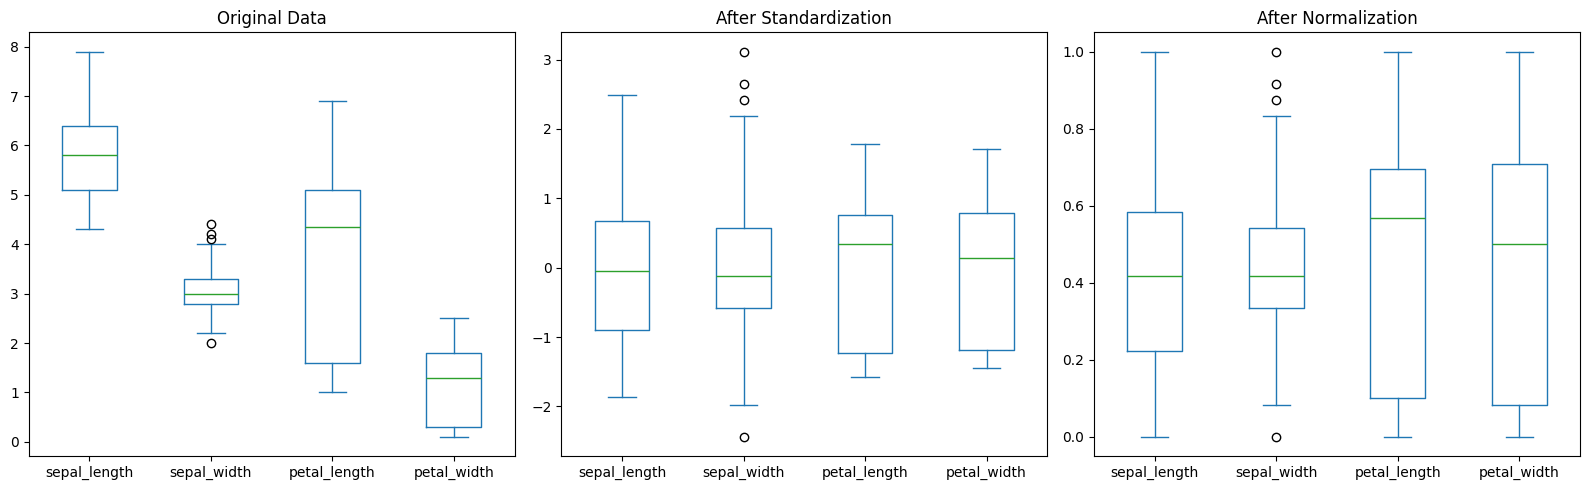

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df[features].plot(kind='box', ax=axes[0], title='Original Data')
df_standardized[features].plot(kind='box', ax=axes[1], title='After Standardization')
df_normalized[features].plot(kind='box', ax=axes[2], title='After Normalization')
plt.tight_layout()
plt.show()

## Step 8: Split Dataset into Training and Testing Sets

In [19]:
X = df_standardized[features]
y = df['species_label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== Dataset Split Summary ===')
print(f'Total samples    : {len(df)}')
print(f'Training samples : {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Testing samples  : {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)')

=== Dataset Split Summary ===
Total samples    : 150
Training samples : 120 (80%)
Testing samples  : 30 (20%)


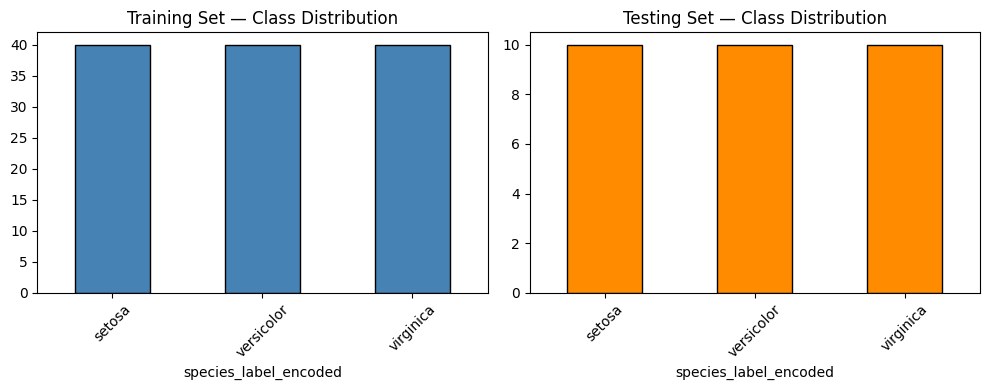

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Training Set — Class Distribution')
axes[0].set_xticklabels(le.classes_, rotation=45)

y_test.value_counts().plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Testing Set — Class Distribution')
axes[1].set_xticklabels(le.classes_, rotation=45)

plt.tight_layout()
plt.show()